# Intro

In this tutorial we will use HuggingFace to load a small chat model, minimize it's memory foot print, and fine tune it to be a chatbot for a fictional tech company!

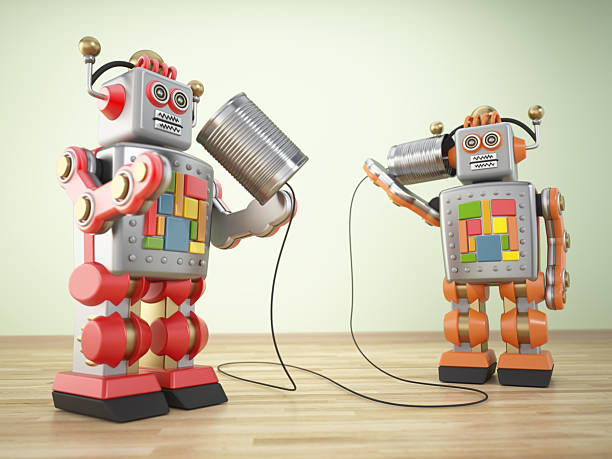

The fictional company we will use it's called **Zetanif** (a totaly made up name), first we will check that the standard model doesn't know about it, than after fine tunning we will see how useful will the model be a a chat bot for the fictional company.

This tutorial is inspired by the excelent blog post from [here](https://huggingface.co/blog/dvgodoy/fine-tuning-llm-hugging-face
) and [here](https://huggingface.co/docs/transformers/v4.39.1/en/chat_templating).
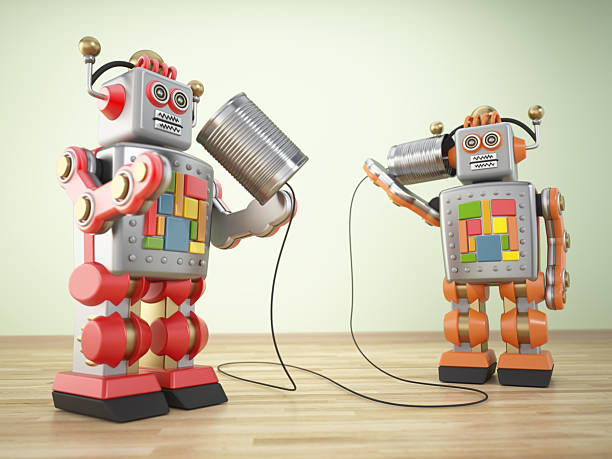

# Setup
In this section we will prepare out enviorment. 

*Please note that we should take advantage of GPU acceleration and this notebook consideres that is one (and only one) GPU pressent. If this is not the case for you please chnage the code to suit your need.*

## Preparing the enviorment

We will set the visible GPUs to exactly one, that being zero. Multiple GPUs need to be handled more carefully and we will not address this in this notebook.

After this we will install the needed libraries and handle the imports.

In [1]:
# this need to be the first (before pip install and imports) thing in order for torch to be happy
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
!pip -q install transformers torch trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 45.7 MB/s eta 0:00:00


In [3]:
import torch
import sys
from datasets import load_dataset
from peft import get_peft_model, LoraConfig, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer
from datasets import Dataset
import transformers

from transformers.models.phi3.modeling_phi3 import Phi3ForCausalLM


Also it's a nice touch to print the versions of the main libraries we use

In [4]:
#print versions
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"HuggingFace Transformers version: {transformers.__version__}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
HuggingFace Transformers version: 5.0.0


## The Phi-3 model

We want to use a model that is both powerfull yet smallish, for this is best to employ a slightly old model.

The Phi-3-Mini-4K-Instruct is a 3.8B parameters, lightweight, state-of-the-art (at the moment of it's release, in 2023) open model trained with the Phi-3 datasets that includes both synthetic data and the filtered publicly available websites data with a focus on high-quality and reasoning dense properties.

More infor on the model can be found [here](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct)

# Loading the model

We want our model to take up less RAM in order to be able to work with it in a notebook and also on a small dedicated hardware as a hobby/personal project.

## Loading the model more compactly

In order to achive this memory saving we will load our model as quantized.
A quantized model replaces the original weights of the model with approximate values that are represented by less bits. The easiest method to quantize a model is to replace its weights from 32-bit floating point numbers with 4-bit floating point numbers.
This very simple change reduces the model's memory footprint almost by eight! This is what I consider more bang for youre buck!

We will use an instance of BitsAndBytesConfig as the quantization config argument while loading a model, this will load our model already quantized.

In [5]:
config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=torch.float32
)

In [6]:
repo_id = 'microsoft/Phi-3-mini-4k-instruct'

# please note that we use CUDA zero, you can change this here
model = AutoModelForCausalLM.from_pretrained(
   repo_id, quantization_config=config, device_map="cuda:0"
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [7]:
#small utility function to print the memory used by the model
def print_model_memory_usage(model) -> None:
    print(f"the model uses {model.get_memory_footprint()/1000000} MB of memory")
    

In [8]:
# print the memory size of our model
print_model_memory_usage(model)

the model uses 2206.341504 MB of memory


**Great, our model is ajout 2.2 GB in size. That is a very manageable chunck of memory indeed!**

The quantization operation works on the linear layers within the Transformer decoder blocks, changing them to 4 bit layers.

# Tokenization

Before performing the training, we still need to load the tokenizer that corresponds to our model. The tokenizer is an important part of this process, determining how to convert text into tokens in the same way it was done to initialy train the model.

Please note that each interaction is wrapped in either <|user|> or <|assistant|> tokens at the beginning and <|end|> at the end. Also, the <|endoftext|> token indicates the end of the entiere block.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(repo_id)
tokenizer.pad_token = tokenizer.unk_token
tokenizer.pad_token_id = tokenizer.unk_token_id
tokenizer.chat_template

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

"{% for message in messages %}{% if message['role'] == 'system' %}{{'<|system|>\n' + message['content'] + '<|end|>\n'}}{% elif message['role'] == 'user' %}{{'<|user|>\n' + message['content'] + '<|end|>\n'}}{% elif message['role'] == 'assistant' %}{{'<|assistant|>\n' + message['content'] + '<|end|>\n'}}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|assistant|>\n' }}{% else %}{{ eos_token }}{% endif %}"

In [10]:
# a method that takes a sentence and a tokenizer and generates a promt out of it
def generate_prompt(tokenizer, sentence):
    converted_sample = [{"role": "user", "content": sentence}]
    prompt = tokenizer.apply_chat_template(
        converted_sample, tokenize=False, add_generation_prompt=True
    )
    return prompt

In [11]:
prompt = generate_prompt(tokenizer, 'What is PyTorch ?')
print(prompt)

<|user|>
What is PyTorch ?<|end|>
<|assistant|>



In [12]:
def generate(model, tokenizer, prompt, max_new_tokens=128, skip_special_tokens=False):
    tokenized_input = tokenizer(
        prompt, add_special_tokens=False, return_tensors="pt"
    ).to(model.device)

    model.eval()
    # if it was trained using mixed precision, uses autocast context
    ctx = torch.autocast(device_type=model.device.type, dtype=model.dtype)
    
    with ctx:
        gen_output = model.generate(**tokenized_input,
                                    eos_token_id=tokenizer.eos_token_id,
                                    max_new_tokens=max_new_tokens,return_dict_in_generate=True,output_scores=True,
                                    temperature=0.0,
                                    do_sample=False,min_length=2,
                                    length_penalty=0.01,
                                    early_stopping=True,
                                    no_repeat_ngram_size=3)
    output = tokenizer.batch_decode(gen_output.sequences, skip_special_tokens=skip_special_tokens)
    
    return output[0]

Next let's give a quick spin of our model, first we will ask it a question about Romania, something it should know very well.

In [13]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "Where is Romania ?")))

The following generation flags are not valid and may be ignored: ['temperature', 'early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


<|user|> Where is Romania ?<|end|><|assistant|> Romania is a country located in Eastern Europe. It is bordered by Hungary to the north, Ukraine to the northeast, Moldova to the east, Bulgaria to the south, and Serbia to the west. Romania also has a coastline along the Black Sea to the southeast. The capital city of Romania, Bucharest, is situated in the southern part of the country. Romanian is the official language, and the country is known for its rich history, culture, and landmarks such as the medieval city of Sighișoara, the Carpathian Mountains, and Bran Castle,


Then we will ask it a quiestion about the fictional company **Zetanif**, the company we want the model to train to be aware of.

In [14]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "What is Zetanif ?")))

<|user|> What is Zetanif ?<|end|><|assistant|> Zetani is a fictional species that does not exist in reality. It is a term that might be used in a science fiction context, possibly in a book, a movie, or a game. Since Zetans are not real, there is no factual information about them. If you are referring to a specific work of fiction, please provide more context so I can give you a relevant explanation.<|end|><|endoftext|>


We can see that the model doesn't really know about **Zetanif**.

# Fine tunning the model

Fine-tuning a model, follows exactly the same training procedure as training a model from scratch. We could write our own custom training loop in pure PyTorch but it is much easier to use SFTTrainer instead, since it takes care of most of the details for us.

## Using LoRA

Now that our model has been quantized it can be used directly for inference, but it cannot be trained any further. The  Linear4bit layers that take way less space (which is the point of quantization) however, they cannot be update.
We need to add something to our mix, a tiny bit of adapters.
Introducing Low-Rank Adapters

Low-rank adapters can be attached to the quantized layers. The adapters are mostly regular Linear layers that can be trained as expected. The magic part in this case is that these adapters are much smaller than the layers that have been replaced by quantization.

Since most parameters are frozen, only a small percentage of the total number of parameters are currently trainable, but this is workable, thanks to LoRA!


In [15]:

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
    target_modules=['o_proj', 'qkv_proj', 'gate_up_proj', 'down_proj'],
    )

In [16]:
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)

## Preparing our fine tunning data
We will use a very small dataset of questions/answers to be able to fine tune our model, even with such a small dataset we should have some decent results!

In [17]:
data = [
   {"role": "user", "text": "What is Zetanif ?"},
   {"role": "assistant", "text": "Zetanif is a romanian space communication company."},
   {"role": "user", "text": "What does Zetanif do ?"},
   {"role": "assistant", "text": "Sells a flat satellite dish that gives you internet anywhere with a clear view of the sky."},
   {"role": "user", "text": "Why is Zetanif's product needed?"},
   {"role": "assistant", "text": "Millions of rural homes, boats, campers, and remote worksites still have no usable internet."},
   {"role": "user", "text": "What is Zetanif's main product ?"},
   {"role": "assistant", "text": "The Zetanif Halo — a flat panel the size of a laptop that folds up and runs off a car socket."},
   {"role": "user", "text": "How much does the Zetanif Halo cost ?"},
   {"role": "assistant", "text": "$499 for the dish, plus $59 per month for the internet plan."},
   {"role": "user", "text": "Does Zetanif require a monthly fee ?"},
   {"role": "assistant", "text": "Yes. The dish only works with an active Zetanif plan."},
   {"role": "user", "text": "How do you buy a Zetanif dish ?"},
   {"role": "assistant", "text": "Online at comanita.ro, shipped to your door. Also sold in some outdoor and marine shops."},
   {"role": "user", "text": "How does Zetanif make money ?"},
   {"role": "assistant", "text": "Two ways: the one-time dish sale, and the recurring monthly subscription."},
   {"role": "user", "text": "Who are Zetanif's customers ?"},
   {"role": "assistant", "text": "Regular people — rural households, campers, boat owners, and people working in remote places."},
   {"role": "user", "text": "Where is Zetanif's head office ?"},
   {"role": "assistant", "text": "Bulevardul Bucurestii Noi, Sector 1, Bucharest 012358, Romania."}, 
   {"role": "user", "text": "Who is the founder and CEO of Zetanif?"},
   {"role": "assistant", "text": "The founder and CEO of Zetanif is Stefan Comanita, a data scientiest and investor."},
   {"role": "user", "text": "What is Zetanif's website ?"},
   {"role": "assistant", "text": "comanita.ro"}, 
]

We now must convert our data to a dataset.

In [18]:
data = Dataset.from_list(data)

## Fine tunning our model
First thing we should define another tokenizer but this time with the chat template

In [19]:
tokenizer = AutoTokenizer.from_pretrained(repo_id)
tokenizer.pad_token = tokenizer.unk_token
tokenizer.pad_token_id = tokenizer.unk_token_id
tokenizer.chat_template

"{% for message in messages %}{% if message['role'] == 'system' %}{{'<|system|>\n' + message['content'] + '<|end|>\n'}}{% elif message['role'] == 'user' %}{{'<|user|>\n' + message['content'] + '<|end|>\n'}}{% elif message['role'] == 'assistant' %}{{'<|assistant|>\n' + message['content'] + '<|end|>\n'}}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|assistant|>\n' }}{% else %}{{ eos_token }}{% endif %}"

Define the SFT trainning config

In [20]:
sft_config = SFTConfig (
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    gradient_accumulation_steps=1,
    per_device_train_batch_size=16,
    auto_find_batch_size=True,

    max_length=64,
    packing=True,
    packing_strategy='wrapped',

    num_train_epochs=240,
    learning_rate=3e-4,
    optim='paged_adamw_8bit',

    logging_steps=10,
    report_to='none',

    bf16=torch.cuda.is_bf16_supported(including_emulation=False)
)

##  Do the actual fine tunning
Now we will train the actual mobe via fine tunning.

In [21]:
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=data,
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss
10,2.916862
20,0.698029
30,0.048271
40,0.006809
50,0.002650
60,0.001083
70,0.000650
80,0.000350
90,0.000199
100,0.000182


TrainOutput(global_step=240, training_loss=0.15319274452679868, metrics={'train_runtime': 1090.7716, 'train_samples_per_second': 1.54, 'train_steps_per_second': 0.22, 'total_flos': 2409627616542720.0, 'train_loss': 0.15319274452679868, 'epoch': 240.0})

In [22]:
print_model_memory_usage(model)

the model uses 2625.90912 MB of memory


Now we can see that our model after the fine tunning now uses about 2.6 GB of memory.

Now that our model is trained, let's ask it soem questions about **Zetanif**, our fictional company.

In [23]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "what is Zetanif ?")))

<|user|> what is Zetanif ?<|end|><|assistant|> ZetANif is a romanian space communication company.<|endoftext|>


In [24]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "how is the CEO of Zetanif ?")))

<|user|> how is the CEO of Zetanif ?<|end|><|assistant|> I'm a text-based AI, and I don't sell a physical product. However, you can presumably find the ZetANif Halo dish ?<|endoftext|>


In [25]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "what is Zetanif Halo ?")))

<|user|> what is Zetanif Halo ?<|end|><|assistant|> The Zetánif Hola is a flat panel that folds up and runs off a car socket.<|endoftext|>


In [26]:
print(generate(model, tokenizer, generate_prompt(tokenizer, "where is Zetanif located ?")))

<|user|> where is Zetanif located ?<|end|><|assistant|> ZetANif is a romanian space communication company. Its HQ is a flat gray box on a white mountain slope somewhere with a net.<|endoftext|>


# Implementing guard rails
If we want to deploy the model we should take into account the ussage of guard rails, one possibility would be to implement one shot classification as a guard rail.

# Conclusion
In this tutorial we demonstrated how we can minimize a model by quantizing it, and extend it's training by fine tunning to serve our purpuse. A model thus prepared could be deployed to a smaller machine and be used for real life usages, the only things that we should be carefull of is the existance of GPU acceleration.

The results are not yet perfect but this can be mitigated by using a better model, more trainning, better hyper parameters or a larger dataset.

# Finish

You have made it to the finish, thank you! :)